# **TEKNIK PENGAMBILAN DAN INTEGRASI  DATA**

Pengambilan Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import glob
import os

In [ ]:
print("Isi drive:")
print(os.listdir('/content/drive/Shared drives/Wrangling/'))


Isi drive:
['Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2021.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2024.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2023.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2022.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2020.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2019.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2018.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2017.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2016.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2015.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2014.csv', 'Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2013.csv', 'Angka Harapan Hidup (AHH) M

In [ ]:
path_BPS = '/content/drive/Shared drives/Wrangling/'
path_jabar = '/content/drive/Shared drives/Wrangling/jabar/'
path_aceh = '/content/drive/Shared drives/Wrangling/Aceh/'

In [ ]:
files_BPS = sorted(glob.glob(os.path.join(path_BPS, '*.csv')))
files_jabar = sorted(glob.glob(os.path.join(path_jabar, '*.csv')))
files_aceh = sorted(glob.glob(os.path.join(path_aceh, '*.csv')))

print("file BPS:", files_BPS)
print("File jabar:", files_jabar)
print("File aceh:", files_aceh)

file BPS: ['/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2010.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2011.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2012.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2013.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2014.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2015.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2016.csv', '/content/drive/Shared drives/Wrangling/Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2017.csv', '/content/drive/Shared drives/Wrangli

In [ ]:
print("Jumlah file ditemukan:", len(files_BPS))
print("Jumlah file ditemukan:", len(files_jabar))
print("Jumlah file ditemukan:", len(files_aceh))

Jumlah file ditemukan: 17
Jumlah file ditemukan: 2
Jumlah file ditemukan: 2


Integrasi Dataset BPS

In [ ]:
data_BPS = []
filtered_files_BPS = [f for f in files_BPS if "gabungan" not in os.path.basename(f).lower()]

for file in filtered_files_BPS:
    year = os.path.basename(file)
    year = year[-8:-4]
    df = pd.read_csv(file, skiprows=3)

    if len(df.columns) == 1 and ';' in df.columns[0]:
        print(f"  -> Suspected wrong separator for {os.path.basename(file)}. Re-reading with sep=';'")
        df = pd.read_csv(file, skiprows=3, sep=';')
    print(f"{os.path.basename(file)} -> kolom: {list(df.columns)}")

    df.columns = ['Provinsi/Kabupaten/Kota', 'Laki-laki', 'Perempuan']
    df['Tahun'] = year
    data_BPS.append(df)

BPS_all = pd.concat(data_BPS, ignore_index=True)
BPS_all = BPS_all.fillna(0)
BPS_all = BPS_all.dropna(subset=['Provinsi/Kabupaten/Kota'])
BPS_all = BPS_all.reset_index(drop=True)

print("Jumlah total baris:", len(BPS_all))
print(BPS_all.head())

output_path = os.path.join(path_BPS, "gabungan_BPS.csv")
BPS_all.to_csv(output_path, index=False, encoding='utf-8-sig')
print("File gabungan disimpan ke:", output_path)

Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2010.csv -> kolom: ['Unnamed: 0', '2010', '2010.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2011.csv -> kolom: ['Unnamed: 0', '2011', '2011.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2012.csv -> kolom: ['Unnamed: 0', '2012', '2012.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2013.csv -> kolom: ['Unnamed: 0', '2013', '2013.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2014.csv -> kolom: ['Unnamed: 0', '2014', '2014.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2015.csv -> kolom: ['Unnamed: 0', '2015', '2015.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2016.csv -> kolom: ['Unnamed: 0', '2016', '2016.1']
Angka Harapan Hidup (AHH) Menurut Kabupaten_Kota dan Jenis Kelamin, 2017.csv -> kolom: ['Unnamed: 0', '2017', '2017.1']
Angka Harapan Hidup (AHH) Menurut Kabupa

In [ ]:
BPS_all

,Provinsi/Kabupaten/Kota,Laki-laki,Perempuan,Tahun
0,ACEH,67.17,71.09,2010
1,Simeulue,62.15,65.84,2010
2,Aceh Singkil,64.76,68.55,2010
3,Aceh Selatan,61.04,64.69,2010
4,Aceh Tenggara,64.9,68.69,2010
...,...,...,...,...
8680,Mamberamo Tengah,62.39,66.21,2024
8681,Yalimo,64.21,68.1,2024
8682,Yahukimo,64.63,68.52,2024
8683,Pegunungan Bintang,63.18,67.04,2024


Dataset Jabar

In [ ]:
import pandas as pd
import os

def read_csv_auto(path):
    try:
        df = pd.read_csv(path)
    except pd.errors.ParserError:
        try:
            df = pd.read_csv(path, sep=';')
        except Exception as e:
            print(f"Error reading {os.path.basename(path)}: {e}")
            return pd.DataFrame()
    if len(df.columns) == 1 and ';' in df.columns[0]:
        print(f"  -> Suspected wrong separator for {os.path.basename(path)}. Re-reading with sep=';'")
        df = pd.read_csv(path, sep=';')
    return df

data_jabar = []
filtered_files_jabar = [f for f in files_jabar if "gabungan_Jabar_clean.csv" not in os.path.basename(f)]

for file in filtered_files_jabar:
    print(f"Memproses: {os.path.basename(file)}")

    df = read_csv_auto(file)
    if df.empty:
        print(f"Failed to read or process {os.path.basename(file)}, skipping.")
        continue
    df.columns = [col.strip() for col in df.columns]
    expected_jabar_cols_present = ['nama_provinsi', 'jenis_kelamin', 'angka_harapan_hidup', 'tahun']

    if all(col in df.columns for col in expected_jabar_cols_present):
        temp_df = df.rename(columns={
            'nama_provinsi': 'Provinsi',
            'jenis_kelamin': 'Jenis Kelamin',
            'angka_harapan_hidup': 'Nilai',
            'tahun': 'Tahun'
        })

        temp_df['Nilai'] = pd.to_numeric(temp_df['Nilai'], errors='coerce')
        temp_df = temp_df.dropna(subset=['Nilai'])
        temp_df['Jenis Kelamin'] = temp_df['Jenis Kelamin'].replace({'LAKI-LAKI': 'Laki-laki', 'PEREMPUAN': 'Perempuan'})

        data_jabar.append(temp_df[['Provinsi', 'Jenis Kelamin', 'Nilai', 'Tahun']])
    else:
        print(f"Jabar file {os.path.basename(file)} does not have expected column structure. Columns found: {df.columns.tolist()}, skipping.")

if data_jabar:
    Jabar_all = pd.concat(data_jabar, ignore_index=True)
else:
    Jabar_all = pd.DataFrame(columns=['Provinsi', 'Jenis Kelamin', 'Nilai', 'Tahun'])

Jabar_all = Jabar_all.dropna(subset=['Provinsi']).reset_index(drop=True)
print("Jumlah total baris:", len(Jabar_all))
print(Jabar_all.head())

output_path = os.path.join(path_jabar, "gabungan_Jabar_clean.csv")
Jabar_all.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"File gabungan disimpan ke: {output_path}")

Memproses: bps-od_19852_angka_harapan_hidup__jk_prov_di_indonesia_v4_data.csv
  -> Suspected wrong separator for bps-od_19852_angka_harapan_hidup__jk_prov_di_indonesia_v4_data.csv. Re-reading with sep=';'
Jumlah total baris: 340
         Provinsi Jenis Kelamin  Nilai  Tahun
0            ACEH     Laki-laki  67.98   2019
1            ACEH     Perempuan  71.85   2019
2  SUMATERA UTARA     Laki-laki  67.07   2019
3  SUMATERA UTARA     Perempuan  70.92   2019
4  SUMATERA BARAT     Laki-laki  67.42   2019
File gabungan disimpan ke: /content/drive/Shared drives/Wrangling/jabar/gabungan_Jabar_clean.csv


In [ ]:
Jabar_all

,Provinsi,Jenis Kelamin,Nilai,Tahun
0,ACEH,Laki-laki,67.98,2019
1,ACEH,Perempuan,71.85,2019
2,SUMATERA UTARA,Laki-laki,67.07,2019
3,SUMATERA UTARA,Perempuan,70.92,2019
4,SUMATERA BARAT,Laki-laki,67.42,2019
...,...,...,...,...
335,MALUKU UTARA,Perempuan,71.14,2023
336,PAPUA BARAT,Laki-laki,64.88,2023
337,PAPUA BARAT,Perempuan,68.81,2023
338,PAPUA,Laki-laki,64.53,2023


Dataset Aceh

In [ ]:
import pandas as pd
import os

path_aceh = "/content/drive/Shared drives/Wrangling/Aceh/"
input_filename = "angka-harapan-hidup-menurut-jenis-kelamin.csv"
input_path = os.path.join(path_aceh, input_filename)

def read_csv_auto(path):
    try:
        df = pd.read_csv(path)
    except pd.errors.ParserError:
        df = pd.read_csv(path, sep=';')
    if len(df.columns) == 1 and ';' in df.columns[0]:
        df = pd.read_csv(path, sep=';')
    return df

df = read_csv_auto(input_path)
print("Kolom sebelum cleaning:", df.columns.tolist())

column_map = {
    'kemendagri_nama_provinsi': 'Provinsi',
    'jenis_kelamin': 'Jenis Kelamin',
    'angka_harapan_hidup': 'Angka Harapan Hidup',
    'tahun': 'Tahun'
}

df.columns = [col.strip() for col in df.columns]
selected_cols = [col for col in column_map.keys() if col in df.columns]

if len(selected_cols) < len(column_map):
    print("Beberapa kolom yang diharapkan tidak ditemukan di file.")
    print("Kolom ditemukan:", df.columns.tolist())

df_clean = df[selected_cols].copy()
df_clean.rename(columns={k: column_map[k] for k in selected_cols}, inplace=True)

if 'Angka Harapan Hidup' in df_clean.columns:
    df_clean['Angka Harapan Hidup'] = pd.to_numeric(df_clean['Angka Harapan Hidup'], errors='coerce')
    df_clean = df_clean.dropna(subset=['Angka Harapan Hidup'])

if 'Jenis Kelamin' in df_clean.columns:
    df_clean['Jenis Kelamin'] = df_clean['Jenis Kelamin'].str.strip().str.title()
    df_clean['Jenis Kelamin'] = df_clean['Jenis Kelamin'].replace({
        'Laki-laki': 'Laki-laki',
        'Perempuan': 'Perempuan',
        'Laki-Laki': 'Laki-laki',
        'Lk': 'Laki-laki',
        'Pr': 'Perempuan'
    })

output_filename = "Aceh_clean.csv"
output_path = os.path.join(path_aceh, output_filename)
df_clean.to_csv(output_path, index=False, encoding='utf-8-sig')

print(f"Cleaning selesai, file disimpan di: {output_path}")
print(df_clean.head())


Kolom sebelum cleaning: ['kemendagri_kode_provinsi', 'kemendagri_nama_provinsi', 'kemendagri_kode_kabupaten_kota', 'kemendagri_nama_kabupaten_kota', 'tahun', 'jenis_kelamin', 'angka_harapan_hidup', 'satuan']
Cleaning selesai, file disimpan di: /content/drive/Shared drives/Wrangling/Aceh/Aceh_clean.csv
  Provinsi Jenis Kelamin  Angka Harapan Hidup  Tahun
0     Aceh     Laki-laki                61.04   2010
1     Aceh     Laki-laki                64.90   2010
2     Aceh     Laki-laki                65.95   2010
3     Aceh     Laki-laki                66.24   2010
4     Aceh     Laki-laki                65.20   2010


In [ ]:
df_clean.head()

,Provinsi,Jenis Kelamin,Angka Harapan Hidup,Tahun
0,Aceh,Laki-laki,61.04,2010
1,Aceh,Laki-laki,64.90,2010
2,Aceh,Laki-laki,65.95,2010
3,Aceh,Laki-laki,66.24,2010
4,Aceh,Laki-laki,65.20,2010


Merge all dataset

In [ ]:
import pandas as pd
import os

output_folder = "/content/drive/Shared drives/Wrangling/output"
os.makedirs(output_folder, exist_ok=True)

BPS_std = BPS_all.copy()
BPS_std = BPS_std.melt(
    id_vars=['Provinsi/Kabupaten/Kota', 'Tahun'],
    value_vars=['Laki-laki', 'Perempuan'],
    var_name='Jenis Kelamin',
    value_name='Nilai'
)

BPS_std.rename(columns={
    'Provinsi/Kabupaten/Kota': 'Kabupaten_Provinsi'
}, inplace=True)

BPS_std['Sumber'] = 'BPS'
BPS_std['Nilai'] = pd.to_numeric(BPS_std['Nilai'], errors='coerce')

Jabar_std = Jabar_all.copy()
Jabar_std.rename(columns={
    'Provinsi': 'Kabupaten_Provinsi',
    'Nilai': 'Nilai'
}, inplace=True)

Jabar_std['Nilai'] = pd.to_numeric(Jabar_std['Nilai'], errors='coerce')
Jabar_std['Sumber'] = 'Jabar'

Aceh_std = df_clean.copy()
Aceh_std.rename(columns={
    'Provinsi': 'Kabupaten_Provinsi',
    'Angka Harapan Hidup': 'Nilai'
}, inplace=True)

Aceh_std['Nilai'] = pd.to_numeric(Aceh_std['Nilai'], errors='coerce')
Aceh_std['Sumber'] = 'Aceh'

gabungan_all = pd.concat([BPS_std, Jabar_std, Aceh_std], ignore_index=True)
gabungan_all = gabungan_all.dropna(subset=['Kabupaten_Provinsi', 'Jenis Kelamin', 'Nilai'])
gabungan_all['Kabupaten_Provinsi'] = gabungan_all['Kabupaten_Provinsi'].str.strip().str.title()

gabungan_all = gabungan_all[['Kabupaten_Provinsi', 'Jenis Kelamin', 'Nilai', 'Tahun', 'Sumber']]
gabungan_all = gabungan_all.reset_index(drop=True)

print("Total baris gabungan:", len(gabungan_all))
print(gabungan_all.head())

output_final = os.path.join(output_folder, "gabungan_final_AHH.csv")
gabungan_all.to_csv(output_final, index=False, encoding='utf-8-sig')

print("File gabungan final disimpan ke:", output_final)


Total baris gabungan: 16114
  Kabupaten_Provinsi Jenis Kelamin  Nilai Tahun Sumber
0               Aceh     Laki-laki  67.17  2010    BPS
1           Simeulue     Laki-laki  62.15  2010    BPS
2       Aceh Singkil     Laki-laki  64.76  2010    BPS
3       Aceh Selatan     Laki-laki  61.04  2010    BPS
4      Aceh Tenggara     Laki-laki  64.90  2010    BPS
File gabungan final disimpan ke: /content/drive/Shared drives/Wrangling/output/gabungan_final_AHH.csv


In [ ]:
gabungan_all

,Kabupaten_Provinsi,Jenis Kelamin,Nilai,Tahun,Sumber
0,Aceh,Laki-laki,67.17,2010,BPS
1,Simeulue,Laki-laki,62.15,2010,BPS
2,Aceh Singkil,Laki-laki,64.76,2010,BPS
3,Aceh Selatan,Laki-laki,61.04,2010,BPS
4,Aceh Tenggara,Laki-laki,64.90,2010,BPS
...,...,...,...,...,...
16109,Aceh,Perempuan,73.33,2020,Aceh
16110,Aceh,Perempuan,72.42,2020,Aceh
16111,Aceh,Perempuan,73.47,2020,Aceh
16112,Aceh,Perempuan,71.34,2020,Aceh


# **DATA CLEANING**

In [ ]:
import os
import re
from typing import List, Optional, Tuple, Dict, Any
import numpy as np
import pandas as pd

INPUT_PATH = "/content/drive/Shared drives/Wrangling/output/gabungan_final_AHH.csv"
CLEANED_OUTPUT_CSV = "/content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH.csv"
BACKUP_CSV = CLEANED_OUTPUT_CSV.replace(".csv", "_backup_original.csv")
SAVE_PARQUET = True
PARQUET_PATH = CLEANED_OUTPUT_CSV.replace(".csv", ".parquet")
MISSING_COL_THRESHOLD = 0.95
MISSING_ROW_THRESHOLD = 0.5
IMPUTE_NUMERIC = True
IMPUTE_CATEGORICAL = True
FORCE_YEAR_COLUMNS = None
TAKE_YEAR_FROM_RANGE = "first"

def read_csv_safely(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"File tidak ditemukan: {path}")
    print(f"Membaca file: {path}")
    return pd.read_csv(path, low_memory=False)

def backup_original(df: pd.DataFrame, backup_path: str):
    print("Membuat backup file asli ke:", backup_path)
    df.to_csv(backup_path, index=False)

def clean_column_names(df: pd.DataFrame) -> pd.DataFrame:
    new_cols = []
    for c in df.columns:
        s = str(c).strip()
        s = s.replace(" ", "_").replace(".", "_").replace("-", "_").replace("/", "_")
        s = re.sub(r"[^0-9a-zA-Z_]+", "", s)
        s = s.lower()
        s = re.sub(r"__+", "_", s)
        s = s.strip("_")
        new_cols.append(s)
    df.columns = new_cols
    return df

def convert_numeric_columns(df: pd.DataFrame, sample_size: int = 200) -> pd.DataFrame:
    obj_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()
    for c in obj_cols:
        sample = df[c].dropna().astype(str).head(sample_size)
        if len(sample) == 0:
            continue
        if any(char.isdigit() for val in sample for char in val):
            try:
                cleaned = df[c].astype(str).str.replace(r"[, ]", "", regex=True)
                df[c] = pd.to_numeric(cleaned.replace({"nan":"", "None":""}), errors="coerce")
            except Exception as e:
                print(f"[convert_numeric_columns] Gagal konversi {c}: {e}")
                continue
    return df

def parse_datetime_columns(df: pd.DataFrame) -> pd.DataFrame:
    candidates = [c for c in df.columns if any(k in c.lower() for k in ["date","tgl","tanggal","waktu","time","tahun","year"])]
    for c in candidates:
        if pd.api.types.is_datetime64_any_dtype(df[c]):
            continue
        try:
            df[c] = pd.to_datetime(df[c], errors="coerce", dayfirst=True)
        except Exception:
            df[c] = pd.to_datetime(df[c], errors="coerce")
    return df

def extract_year_from_string(val: Any, prefer: str = "first") -> Optional[int]:
    if pd.isna(val):
        return None
    s = str(val)
    if isinstance(val, (pd.Timestamp, np.datetime64)):
        try:
            return int(pd.to_datetime(val).year)
        except Exception:
            return None
    matches = re.findall(r"\b(19|20)\d{2}\b", s)
    matches_iter = [m.group(0) for m in re.finditer(r"\b(19|20)\d{2}\b", s)]
    if matches_iter:
        if len(matches_iter) == 1:
            return int(matches_iter[0])
        else:
            return int(matches_iter[0]) if prefer == "first" else int(matches_iter[-1])
    m = re.search(r"(19|20)\d{2}", s)
    if m:
        return int(m.group(0))
    return None

def clean_year_columns(df: pd.DataFrame, year_cols: Optional[List[str]] = None, prefer: str = "first") -> pd.DataFrame:
    if year_cols is None:
        year_cols = [c for c in df.columns if any(k in c.lower() for k in ["tahun", "year", "thn"])]
    print("Kolom tahun yang akan dibersihkan:", year_cols)
    for col in year_cols:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            df[col] = df[col].dt.year
        else:
            df[col] = df[col].apply(lambda x: extract_year_from_string(x, prefer=prefer))
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int64")
    return df

def drop_constant_columns(df: pd.DataFrame) -> Tuple[pd.DataFrame, List[str]]:
    const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
    if const_cols:
        print(f"Men-drop {len(const_cols)} kolom konstan.")
        df = df.drop(columns=const_cols)
    return df, const_cols

def drop_high_missing_columns(df: pd.DataFrame, threshold: float = MISSING_COL_THRESHOLD) -> Tuple[pd.DataFrame, List[str]]:
    missing_pct = df.isna().mean()
    drop_cols = missing_pct[missing_pct > threshold].index.tolist()
    if drop_cols:
        print(f"Men-drop {len(drop_cols)} kolom karena > {threshold*100:.0f}% missing.")
        df = df.drop(columns=drop_cols)
    return df, drop_cols

def handle_missing_values(df: pd.DataFrame,
                          drop_row_threshold: Optional[float] = MISSING_ROW_THRESHOLD,
                          impute_numeric: bool = IMPUTE_NUMERIC,
                          impute_categorical: bool = IMPUTE_CATEGORICAL) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    actions = {"dropped_rows": 0, "imputed_numeric": [], "imputed_categorical": []}

    if drop_row_threshold is not None and 0 < drop_row_threshold < 1:
        before = df.shape[0]
        df = df[df.isna().mean(axis=1) <= drop_row_threshold].reset_index(drop=True)
        actions["dropped_rows"] = before - df.shape[0]
        if actions["dropped_rows"] > 0:
            print(f"Dropped {actions['dropped_rows']} baris karena > {drop_row_threshold*100:.0f}% missing per row.")

    if impute_numeric:
        num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for c in num_cols:
            if df[c].isna().any():
                median = df[c].median(skipna=True)
                if pd.isna(median):
                    continue
                df[c] = df[c].fillna(median)
                actions["imputed_numeric"].append((c, median))
        if actions["imputed_numeric"]:
            print(f"Imputed numeric columns: {len(actions['imputed_numeric'])}")

    if impute_categorical:
        cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
        for c in cat_cols:
            if df[c].isna().any():
                try:
                    mode = df[c].mode(dropna=True)
                    if len(mode) > 0:
                        fill = mode.iloc[0]
                        df[c] = df[c].fillna(fill)
                        actions["imputed_categorical"].append((c, fill))
                except Exception:
                    continue
        if actions["imputed_categorical"]:
            print(f"Imputed categorical columns: {len(actions['imputed_categorical'])}")

    return df, actions

def remove_exact_duplicates(df: pd.DataFrame) -> Tuple[pd.DataFrame, int]:
    before = df.shape[0]
    df = df.drop_duplicates().reset_index(drop=True)
    removed = before - df.shape[0]
    if removed > 0:
        print(f"Removed {removed} exact duplicate rows (double identik).")
    return df, removed

def summarize(df: pd.DataFrame):
    print("----- Summary -----")
    print("Shape:", df.shape)
    print("Kolom sample (max 30):", df.columns.tolist()[:30])
    print("Top 10 missing percent:")
    print((df.isna().mean().sort_values(ascending=False).head(10) * 100).round(2))

def save_outputs(df: pd.DataFrame, csv_path: str, parquet_path: Optional[str] = None):
    df.to_csv(csv_path, index=False)
    print("Saved cleaned CSV to:", csv_path)
    if parquet_path:
        try:
            df.to_parquet(parquet_path, index=False)
            print("Saved parquet to:", parquet_path)
        except Exception as e:
            print("Gagal simpan parquet:", e)

def run_cleaning(input_path: str = INPUT_PATH,
                 cleaned_output: str = CLEANED_OUTPUT_CSV,
                 backup_path: str = BACKUP_CSV,
                 force_year_cols: Optional[List[str]] = FORCE_YEAR_COLUMNS):
    df = read_csv_safely(input_path)
    backup_original(df, backup_path)

    print("Shape awal:", df.shape)

    df = clean_column_names(df)
    df = parse_datetime_columns(df)
    df = convert_numeric_columns(df)
    df = clean_year_columns(df, year_cols=force_year_cols, prefer=TAKE_YEAR_FROM_RANGE)
    df, const_cols = drop_constant_columns(df)
    df, dropped_missing_cols = drop_high_missing_columns(df, threshold=MISSING_COL_THRESHOLD)
    df, removed_dupes = remove_exact_duplicates(df)
    df, missing_actions = handle_missing_values(df,
                                                drop_row_threshold=MISSING_ROW_THRESHOLD,
                                                impute_numeric=IMPUTE_NUMERIC,
                                                impute_categorical=IMPUTE_CATEGORICAL)
    df = df.reset_index(drop=True)
    summarize(df)

    save_outputs(df, cleaned_output, PARQUET_PATH if SAVE_PARQUET else None)
    result_summary = {
        "cleaned_csv": cleaned_output,
        "parquet": PARQUET_PATH if SAVE_PARQUET else None,
        "initial_shape": None,
        "final_shape": df.shape,
        "dropped_constant_cols": const_cols,
        "dropped_high_missing_cols": dropped_missing_cols,
        "removed_exact_duplicates": removed_dupes,
        "missing_actions": missing_actions
    }
    return df, result_summary

if __name__ == "__main__":
    df_cleaned, summary = run_cleaning()
    print("Proses cleaning selesai.")
    print("Ringkasan:", {k: summary[k] for k in ["final_shape","removed_exact_duplicates","dropped_constant_cols","dropped_high_missing_cols"]})

Membaca file: /content/drive/Shared drives/Wrangling/output/gabungan_final_AHH.csv
Membuat backup file asli ke: /content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH_backup_original.csv
Shape awal: (16114, 5)
Kolom tahun yang akan dibersihkan: ['tahun']
Men-drop 1 kolom konstan.
Removed 489 exact duplicate rows (double identik).
----- Summary -----
Shape: (15625, 4)
Kolom sample (max 30): ['kabupaten_provinsi', 'jenis_kelamin', 'nilai', 'sumber']
Top 10 missing percent:
kabupaten_provinsi    0.0
jenis_kelamin         0.0
nilai                 0.0
sumber                0.0
dtype: float64
Saved cleaned CSV to: /content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH.csv
Saved parquet to: /content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH.parquet
Proses cleaning selesai.
Ringkasan: {'final_shape': (15625, 4), 'removed_exact_duplicates': 489, 'dropped_constant_cols': ['tahun'], 'dropped_high_missing_cols': []}


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH_backup_original.csv")
df.head()


,Kabupaten_Provinsi,Jenis Kelamin,Nilai,Tahun,Sumber
0,Aceh,Laki-laki,67.17,2010,BPS
1,Simeulue,Laki-laki,62.15,2010,BPS
2,Aceh Singkil,Laki-laki,64.76,2010,BPS
3,Aceh Selatan,Laki-laki,61.04,2010,BPS
4,Aceh Tenggara,Laki-laki,64.90,2010,BPS


preprocessing

In [ ]:
import os
from typing import Optional, List
import numpy as np
import pandas as pd

CLEANED_INPUT_CSV = "/content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH_backup_original.csv"
OUT_PROV_YEAR = "/content/drive/Shared drives/Wrangling/output/ahh_by_province_year.csv"
OUT_PROV_YEAR_GENDER = "/content/drive/Shared drives/Wrangling/output/ahh_by_province_year_gender.csv"
OUT_PROC_PROV = "/content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province.csv"
OUT_PROC_PROV_GENDER = "/content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province_gender.csv"

PROVINCE_KEYWORDS = ["provinsi", "prov", "province", "nama_provinsi", "nama_prov"]
AHH_KEYWORDS = ["ahh", "angka_harapan_hidup", "life_expectancy", "life", "angka_harap", "harapan_hidup", "nilai"]
YEAR_KEYWORDS = ["tahun", "year", "y"]
GENDER_KEYWORDS = ["gender", "sex", "jenis_kelamin", "jk", "kelamin"]

def find_column_by_keywords(cols: List[str], keywords: List[str]) -> Optional[str]:
    cols_lower = [c.lower() for c in cols]
    for kw in keywords:
        for i, c in enumerate(cols_lower):
            if kw in c:
                return cols[i]
    return None

def normalize_year_column(df: pd.DataFrame, col_name: str, new_col: str = "year") -> pd.DataFrame:
    s = df[col_name]
    if pd.api.types.is_datetime64_any_dtype(s):
        df[new_col] = pd.DatetimeIndex(s).year.astype("Int64")
        return df

    if s.dtype == object or pd.api.types.is_string_dtype(s):
        years = s.astype(str).str.extract(r'(?P<y>(19|20)\d{2})', expand=True)['y']
        if years.notna().sum() > 0:
            df[new_col] = pd.to_numeric(years, errors='coerce').astype("Int64")
            return df
        try:
            parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
            if parsed.notna().sum() > 0:
                df[new_col] = pd.DatetimeIndex(parsed).year.astype("Int64")
                return df
        except Exception:
            pass

    if pd.api.types.is_integer_dtype(s) or pd.api.types.is_float_dtype(s) or pd.api.types.is_numeric_dtype(s):
        numeric = pd.to_numeric(s, errors='coerce')
        nonnull = numeric.dropna()
        if nonnull.size > 0:
            frac_years = ((nonnull >= 1900) & (nonnull <= 2100)).sum() / nonnull.size
            if frac_years > 0.5:
                df[new_col] = numeric.round().astype("Int64")
                return df
    try:
        parsed = pd.to_datetime(s.astype(str), errors='coerce', dayfirst=True)
        if parsed.notna().sum() > 0:
            df[new_col] = pd.DatetimeIndex(parsed).year.astype("Int64")
            return df
    except Exception:
        pass

    df[new_col] = pd.Series([pd.NA] * len(df), dtype="Int64")
    return df

def build_full_panel_and_interpolate(df_agg: pd.DataFrame, group_cols: List[str], value_col: str = "ahh_mean") -> pd.DataFrame:
    frames = []
    groups = df_agg.groupby(group_cols, dropna=False)
    for name, group in groups:
        sub = group.copy()
        sub['year_int'] = pd.to_numeric(sub['year'], errors='coerce').astype('Int64')
        years = sub['year_int'].dropna().astype(int).tolist()
        if not years:
            continue
        y_min, y_max = min(years), max(years)
        full_years = pd.DataFrame({'year': list(range(y_min, y_max + 1))})
        for i, gc in enumerate(group_cols):
            if isinstance(name, tuple):
                full_years[gc] = name[i]
            else:
                full_years[gc] = name
        merged = full_years.merge(sub, on=group_cols + ['year'], how='left', suffixes=('', '_orig'))
        merged[value_col] = merged[value_col].interpolate(method='linear', limit_direction='both')
        if 'observations' in merged.columns:
            merged['observations'] = merged['observations'].fillna(0).astype(int)
        else:
            merged['observations'] = 0
        frames.append(merged)
    if frames:
        panel = pd.concat(frames, ignore_index=True, sort=False)
    else:
        panel = pd.DataFrame(columns=group_cols + ['year', value_col, 'observations'])
    panel['year'] = pd.to_numeric(panel['year'], errors='coerce').astype('Int64')
    panel[value_col] = pd.to_numeric(panel[value_col], errors='coerce')
    return panel

def preprocess_for_trend(
    input_cleaned_csv: str = CLEANED_INPUT_CSV,
    out_prov_year: str = OUT_PROV_YEAR,
    out_prov_year_gender: str = OUT_PROV_YEAR_GENDER,
    out_proc_prov: str = OUT_PROC_PROV,
    out_proc_prov_gender: str = OUT_PROC_PROV_GENDER,
    do_ohe: bool = False
):
    if not os.path.exists(input_cleaned_csv):
        raise FileNotFoundError(f"File cleaned tidak ditemukan: {input_cleaned_csv}")
    print("Membaca cleaned CSV:", input_cleaned_csv)
    df = pd.read_csv(input_cleaned_csv, low_memory=False)
    print("Shape input:", df.shape)

    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    prov_col = find_column_by_keywords(df.columns.tolist(), PROVINCE_KEYWORDS)
    ahh_col = find_column_by_keywords(df.columns.tolist(), AHH_KEYWORDS)
    year_col = find_column_by_keywords(df.columns.tolist(), YEAR_KEYWORDS)
    gender_col = find_column_by_keywords(df.columns.tolist(), GENDER_KEYWORDS)

    print("Detected columns -> province:", prov_col, " | ahh:", ahh_col, " | year:", year_col, " | gender:", gender_col)

    if prov_col is None:
        candidates = [c for c in df.columns if (df[c].nunique(dropna=True) < 40 and df[c].nunique(dropna=True) > 1)]
        prov_col = candidates[0] if candidates else None
        print("Fallback province col:", prov_col)

    if ahh_col is None:
        raise ValueError("Kolom AHH tidak terdeteksi. Periksa nama kolom pada file cleaned.")

    if prov_col is None:
        raise ValueError("Kolom provinsi tidak terdeteksi. Mohon sebutkan nama kolom provinsi atau ubah header file cleaned.")

    df = df.rename(columns={prov_col: 'province'})
    prov_col = 'province'
    if gender_col:
        df = df.rename(columns={gender_col: 'gender'})
        gender_col = 'gender'
    if year_col:
        df = normalize_year_column(df, year_col, new_col='year')
    else:
        df['year'] = pd.Series([pd.NA] * len(df), dtype='Int64')

    df[ahh_col] = pd.to_numeric(df[ahh_col], errors='coerce')
    df_valid_year = df[df['year'].notna()].copy()
    print("Rows with valid year:", df_valid_year.shape[0])

    agg_prov_year = df_valid_year.groupby(['province', 'year'], dropna=False).agg(
        ahh_mean = (ahh_col, 'mean'),
        ahh_median = (ahh_col, 'median'),
        observations = (ahh_col, lambda x: int(x.notna().sum()))
    ).reset_index()

    agg_prov_year.to_csv(out_prov_year, index=False)
    print("Saved province-year aggregate to:", out_prov_year)

    panel_prov = build_full_panel_and_interpolate(agg_prov_year, group_cols=['province'], value_col='ahh_mean')
    panel_prov = panel_prov.sort_values(['province', 'year']).reset_index(drop=True)
    panel_prov['ahh_rolling_3'] = panel_prov.groupby('province')['ahh_mean'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
    panel_prov['ahh_yoy_diff'] = panel_prov.groupby('province')['ahh_mean'].transform(lambda x: x.diff(periods=1))
    panel_prov['ahh_yoy_pct'] = panel_prov.groupby('province')['ahh_mean'].transform(lambda x: x.pct_change(periods=1))

    global_mean = panel_prov['ahh_mean'].mean(skipna=True)
    panel_prov['ahh_mean'] = panel_prov['ahh_mean'].fillna(global_mean)
    panel_prov['ahh_rolling_3'] = panel_prov['ahh_rolling_3'].fillna(panel_prov['ahh_mean'])

    keep_cols_prov = ['province', 'year', 'ahh_mean', 'ahh_median', 'observations',
                      'ahh_rolling_3', 'ahh_yoy_diff', 'ahh_yoy_pct']
    proc_prov = panel_prov[keep_cols_prov].copy()
    proc_prov.to_csv(out_proc_prov, index=False)
    print("Saved processed province trend CSV to:", out_proc_prov)

    if gender_col and gender_col in df_valid_year.columns:
        agg_prov_year_gender = df_valid_year.groupby(['province', 'gender', 'year'], dropna=False).agg(
            ahh_mean = (ahh_col, 'mean'),
            ahh_median = (ahh_col, 'median'),
            observations = (ahh_col, lambda x: int(x.notna().sum()))
        ).reset_index()
        agg_prov_year_gender.to_csv(out_prov_year_gender, index=False)
        print("Saved province-year-gender aggregate to:", out_prov_year_gender)

        panel_prov_gender = build_full_panel_and_interpolate(agg_prov_year_gender, group_cols=['province','gender'], value_col='ahh_mean')
        panel_prov_gender = panel_prov_gender.sort_values(['province','gender','year']).reset_index(drop=True)
        panel_prov_gender['ahh_rolling_3'] = panel_prov_gender.groupby(['province','gender'])['ahh_mean'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())
        panel_prov_gender['ahh_yoy_diff'] = panel_prov_gender.groupby(['province','gender'])['ahh_mean'].transform(lambda x: x.diff(periods=1))
        panel_prov_gender['ahh_yoy_pct'] = panel_prov_gender.groupby(['province','gender'])['ahh_mean'].transform(lambda x: x.pct_change(periods=1))

        global_mean_g = panel_prov_gender['ahh_mean'].mean(skipna=True)
        panel_prov_gender['ahh_mean'] = panel_prov_gender['ahh_mean'].fillna(global_mean_g)
        panel_prov_gender['ahh_rolling_3'] = panel_prov_gender['ahh_rolling_3'].fillna(panel_prov_gender['ahh_mean'])

        keep_cols_pg = ['province','gender','year','ahh_mean','ahh_median','observations','ahh_rolling_3','ahh_yoy_diff','ahh_yoy_pct']
        proc_prov_gender = panel_prov_gender[keep_cols_pg].copy()
        proc_prov_gender.to_csv(out_proc_prov_gender, index=False)
        print("Saved processed province+gender trend CSV to:", out_proc_prov_gender)
    else:
        print("Kolom gender tidak ditemukan atau tidak valid. Lewati pembuatan file province-year-gender.")

    print("Selesai preprocessing tren AHH.")
    outputs = {
        "agg_prov_year": out_prov_year,
        "processed_prov": out_proc_prov
    }
    if gender_col and gender_col in df_valid_year.columns:
        outputs["agg_prov_year_gender"] = out_prov_year_gender
        outputs["processed_prov_gender"] = out_proc_prov_gender
    return outputs

if __name__ == "__main__":
    result = preprocess_for_trend()
    print("Outputs:", result)


Membaca cleaned CSV: /content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH_backup_original.csv
Shape input: (16114, 5)
Detected columns -> province: kabupaten_provinsi  | ahh: nilai  | year: tahun  | gender: jenis_kelamin
Rows with valid year: 16114
Saved province-year aggregate to: /content/drive/Shared drives/Wrangling/output/ahh_by_province_year.csv
Saved processed province trend CSV to: /content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province.csv
Saved province-year-gender aggregate to: /content/drive/Shared drives/Wrangling/output/ahh_by_province_year_gender.csv
Saved processed province+gender trend CSV to: /content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province_gender.csv
Selesai preprocessing tren AHH.
Outputs: {'agg_prov_year': '/content/drive/Shared drives/Wrangling/output/ahh_by_province_year.csv', 'processed_prov': '/content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province.csv', 'agg_prov_year_gender': 

In [ ]:
df = pd.read_csv("/content/drive/Shared drives/Wrangling/output/ahh_by_province_year.csv")
df.head()

,province,year,ahh_mean,ahh_median,observations
0,Aceh,2010,67.331458,67.255,48
1,Aceh,2011,67.390417,67.315,48
2,Aceh,2012,67.438125,67.370,48
3,Aceh,2013,67.473958,67.420,48
4,Aceh,2014,67.492083,67.445,48


In [ ]:
df = pd.read_csv("/content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province.csv")
df.head()

,province,year,ahh_mean,ahh_median,observations,ahh_rolling_3,ahh_yoy_diff,ahh_yoy_pct
0,Aceh,2010,67.331458,67.255,48,67.331458,NaN,NaN
1,Aceh,2011,67.390417,67.315,48,67.360938,0.058958,0.000876
2,Aceh,2012,67.438125,67.370,48,67.386667,0.047708,0.000708
3,Aceh,2013,67.473958,67.420,48,67.434167,0.035833,0.000531
4,Aceh,2014,67.492083,67.445,48,67.468056,0.018125,0.000269


In [ ]:
df = pd.read_csv("/content/drive/Shared drives/Wrangling/output/ahh_by_province_year_gender.csv")
df.head()

,province,gender,year,ahh_mean,ahh_median,observations
0,Aceh,Laki-laki,2010,65.426250,66.220,24
1,Aceh,Laki-laki,2011,65.484167,66.275,24
2,Aceh,Laki-laki,2012,65.531250,66.300,24
3,Aceh,Laki-laki,2013,65.567083,66.340,24
4,Aceh,Laki-laki,2014,65.585000,66.360,24


In [ ]:
df = pd.read_csv("/content/drive/Shared drives/Wrangling/output/processed_trend_AHH_province_gender.csv")
df.head()

,province,gender,year,ahh_mean,ahh_median,observations,ahh_rolling_3,ahh_yoy_diff,ahh_yoy_pct
0,Aceh,Laki-laki,2010,65.426250,66.220,24,65.426250,NaN,NaN
1,Aceh,Laki-laki,2011,65.484167,66.275,24,65.455208,0.057917,0.000885
2,Aceh,Laki-laki,2012,65.531250,66.300,24,65.480556,0.047083,0.000719
3,Aceh,Laki-laki,2013,65.567083,66.340,24,65.527500,0.035833,0.000547
4,Aceh,Laki-laki,2014,65.585000,66.360,24,65.561111,0.017917,0.000273


# **DATA EXPLORASI**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/Shared drives/Wrangling/output/cleaned_gabungan_final_AHH_backup_original.csv")
df["Tahun"] = pd.to_numeric(df["Tahun"], errors="coerce")

df.head()

,Kabupaten_Provinsi,Jenis Kelamin,Nilai,Tahun,Sumber
0,Aceh,Laki-laki,67.17,2010,BPS
1,Simeulue,Laki-laki,62.15,2010,BPS
2,Aceh Singkil,Laki-laki,64.76,2010,BPS
3,Aceh Selatan,Laki-laki,61.04,2010,BPS
4,Aceh Tenggara,Laki-laki,64.90,2010,BPS


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16114 entries, 0 to 16113
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Kabupaten_Provinsi  16114 non-null  object 
 1   Jenis Kelamin       16114 non-null  object 
 2   Nilai               16114 non-null  float64
 3   Tahun               16114 non-null  int64  
 4   Sumber              16114 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 629.6+ KB


Mengetahui perkembangan tren angka harapan hidup di Indonesia

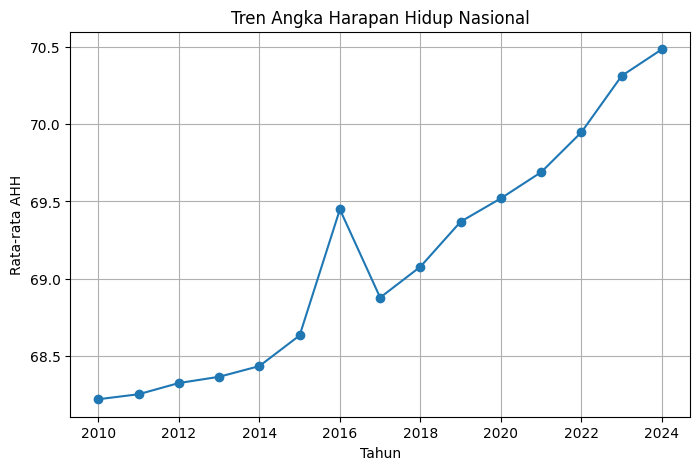

Visualisasi berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/tren_ahh_nasional.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"

os.makedirs(drive_folder, exist_ok=True)
trend_nasional = df.groupby("Tahun")["Nilai"].mean().reset_index()

plt.figure(figsize=(8,5))
plt.plot(trend_nasional["Tahun"], trend_nasional["Nilai"], marker="o")
plt.title("Tren Angka Harapan Hidup Nasional")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata AHH")
plt.grid(True)

save_path = os.path.join(drive_folder, "tren_ahh_nasional.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Visualisasi berhasil disimpan di: {save_path}")

In [ ]:
trend_nasional

,Tahun,Nilai
0,2010,68.220610
1,2011,68.252795
2,2012,68.325329
3,2013,68.365703
4,2014,68.434991
5,2015,68.633348
6,2016,69.448714
7,2017,68.878129
8,2018,69.078138
9,2019,69.369315


Membandingkan angka harapan hidup laki-laki dan perempuan

In [ ]:
gender_mean = df.groupby("Jenis Kelamin")["Nilai"].mean()
print(gender_mean)

Jenis Kelamin
Laki-laki    67.208126
Perempuan    71.031410
Name: Nilai, dtype: float64


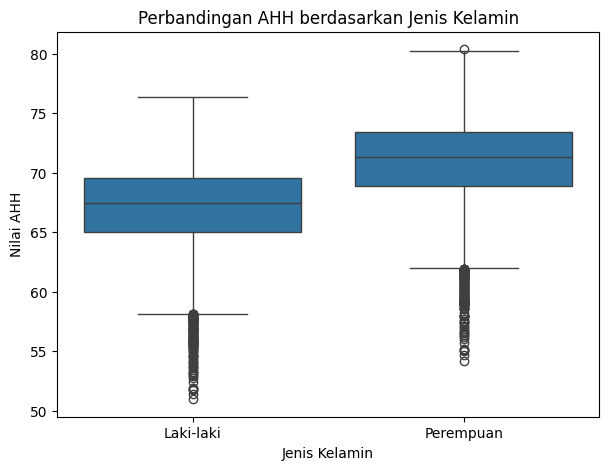

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/boxplot_ahh_gender.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="Jenis Kelamin", y="Nilai")
plt.title("Perbandingan AHH berdasarkan Jenis Kelamin")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Nilai AHH")

save_path = os.path.join(drive_folder, "boxplot_ahh_gender.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Gambar berhasil disimpan di: {save_path}")

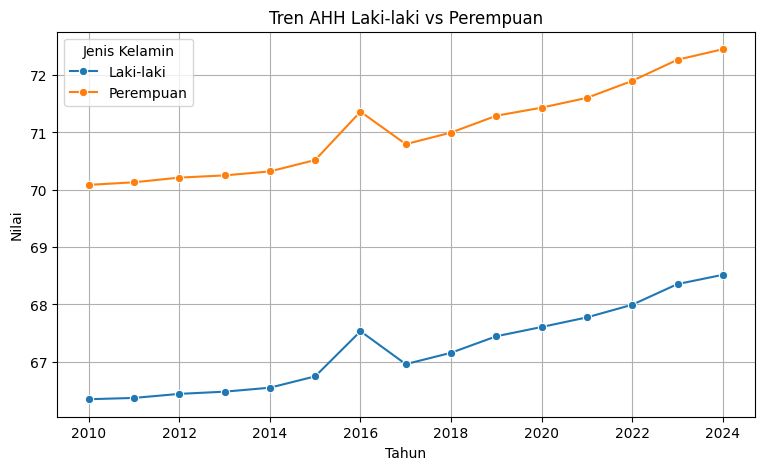

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/tren_ahh_gender.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"

os.makedirs(drive_folder, exist_ok=True)
trend_gender = df.groupby(["Tahun","Jenis Kelamin"])["Nilai"].mean().reset_index()

plt.figure(figsize=(9,5))
sns.lineplot(
    data=trend_gender,
    x="Tahun",
    y="Nilai",
    hue="Jenis Kelamin",
    marker="o"
)
plt.title("Tren AHH Laki-laki vs Perempuan")
plt.grid(True)

save_path = os.path.join(drive_folder, "tren_ahh_gender.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Gambar berhasil disimpan di: {save_path}")

In [ ]:
trend_gender

,Tahun,Jenis Kelamin,Nilai
0,2010,Laki-laki,66.347907
1,2010,Perempuan,70.086402
2,2011,Laki-laki,66.370596
3,2011,Perempuan,70.131604
4,2012,Laki-laki,66.441115
5,2012,Perempuan,70.212937
6,2013,Laki-laki,66.479631
7,2013,Perempuan,70.251775
8,2014,Laki-laki,66.548864
9,2014,Perempuan,70.321119


/tmp/ipython-input-1506461784.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


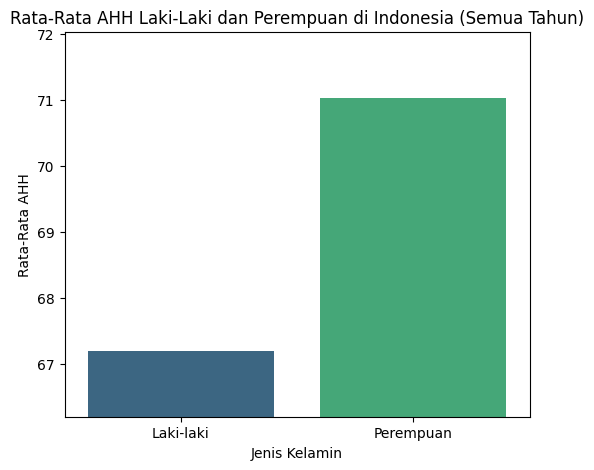

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/rata_rata_ahh_gender.png


,Jenis Kelamin,Nilai
0,Laki-laki,67.208126
1,Perempuan,71.031410


In [ ]:
df["Nilai"] = pd.to_numeric(df["Nilai"], errors="coerce")
df["Tahun"] = pd.to_numeric(df["Tahun"], errors="coerce")

drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

df_gender_mean = (
    df.groupby("Jenis Kelamin")["Nilai"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(6,5))
sns.barplot(
    data=df_gender_mean,
    x="Jenis Kelamin",
    y="Nilai",
    palette="viridis"
)

plt.title("Rata-Rata AHH Laki-Laki dan Perempuan di Indonesia (Semua Tahun)")
plt.xlabel("Jenis Kelamin")
plt.ylabel("Rata-Rata AHH")
plt.ylim(df_gender_mean["Nilai"].min() - 1, df_gender_mean["Nilai"].max() + 1)

save_path = os.path.join(drive_folder, "rata_rata_ahh_gender.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gambar berhasil disimpan di:", save_path)

df_gender_mean

Menganalisis faktor yang memengaruhi AHH laki-laki vs perempuan

In [ ]:
df.groupby("Jenis Kelamin")["Nilai"].describe()

,count,mean,std,min,25%,50%,75%,max
Jenis Kelamin,,,,,,,,
Laki-laki,8056.0,67.208126,3.553785,50.98,65.00,67.44,69.57,76.40
Perempuan,8058.0,71.031410,3.597133,54.22,68.85,71.32,73.43,80.38


In [ ]:
corr_gender = (
    df.groupby("Jenis Kelamin")
      .apply(lambda x: x[["Nilai","Tahun"]].corr().iloc[0,1])
)
corr_gender

/tmp/ipython-input-3850577708.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x[["Nilai","Tahun"]].corr().iloc[0,1])


,0
Jenis Kelamin,
Laki-laki,0.199028
Perempuan,0.212021


In [ ]:
gap = (
    df.groupby(["Tahun","Jenis Kelamin"])["Nilai"].mean()
      .unstack()
)
gap["gap_perempuan_laki"] = gap["Perempuan"] - gap["Laki-laki"]
gap

Jenis Kelamin,Laki-laki,Perempuan,gap_perempuan_laki
Tahun,,,
2010,66.347907,70.086402,3.738495
2011,66.370596,70.131604,3.761008
2012,66.441115,70.212937,3.771822
2013,66.479631,70.251775,3.772144
2014,66.548864,70.321119,3.772255
2015,66.746853,70.519843,3.772990
2016,67.534000,71.363429,3.829429
2017,66.959476,70.796783,3.837308
2018,67.158007,70.998269,3.840262


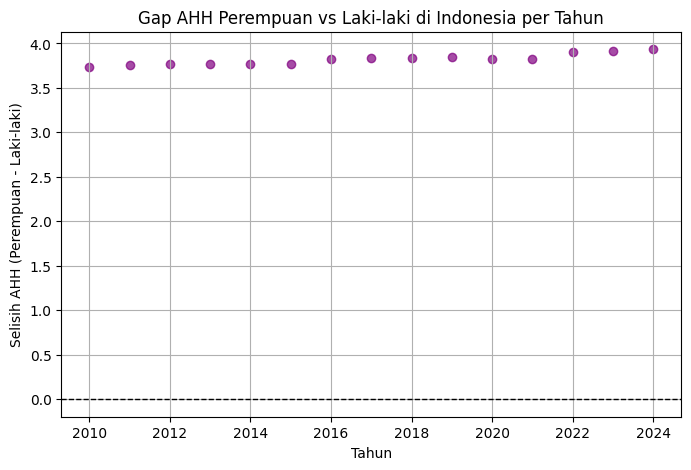

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/gap_ahh_gender.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

gap = (
    df.groupby(["Tahun", "Jenis Kelamin"])["Nilai"]
      .mean()
      .unstack()
)

gap["gap_perempuan_laki"] = gap["Perempuan"] - gap["Laki-laki"]

plt.figure(figsize=(8,5))
plt.scatter(gap.index, gap["gap_perempuan_laki"], color="purple", alpha=0.7)

plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Tahun")
plt.ylabel("Selisih AHH (Perempuan - Laki-laki)")
plt.title("Gap AHH Perempuan vs Laki-laki di Indonesia per Tahun")
plt.grid(True)

save_path = os.path.join(drive_folder, "gap_ahh_gender.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

plt.show()

print("Gambar berhasil disimpan di:", save_path)

Mengidentifikasi pola khusus per wilayah

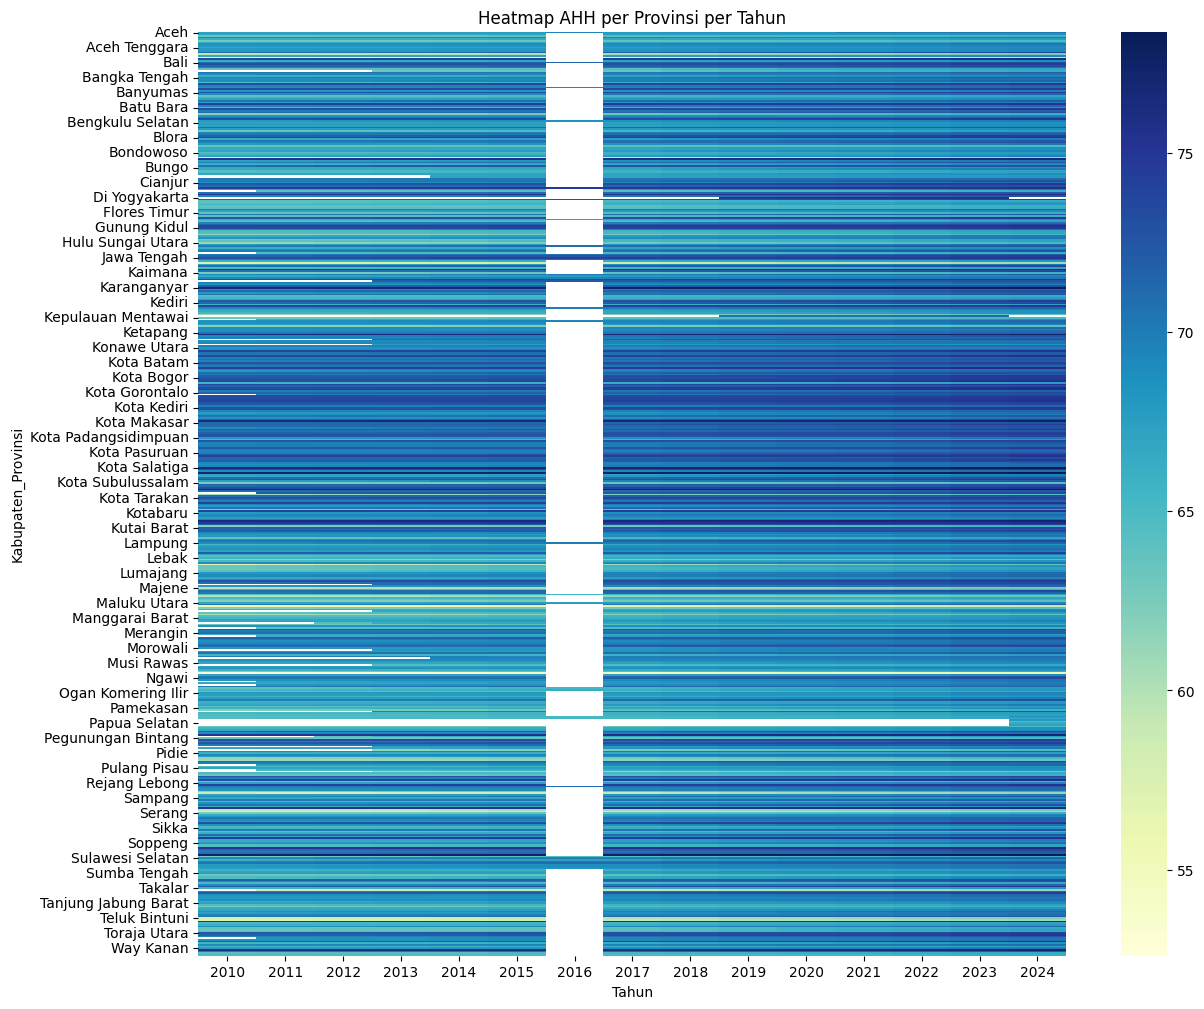

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/heatmap_ahh_provinsi_tahun.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

pivot_map = df.pivot_table(
    index="Kabupaten_Provinsi",
    columns="Tahun",
    values="Nilai"
)

plt.figure(figsize=(14,12))
sns.heatmap(pivot_map, cmap="YlGnBu")

plt.title("Heatmap AHH per Provinsi per Tahun")
save_path = os.path.join(drive_folder, "heatmap_ahh_provinsi_tahun.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gambar berhasil disimpan di:", save_path)

Tren AHH 5 Provinsi Tertinggi

In [ ]:
top10 = df.groupby("Kabupaten_Provinsi")["Nilai"].mean().sort_values(ascending=False).head(10)
top10

,Nilai
Kabupaten_Provinsi,
Sukoharjo,77.645357
Kota Semarang,77.404286
Karanganyar,77.221786
Kota Surakarta,77.186071
Kota Salatiga,77.084643
Kota Magelang,76.761429
Klaten,76.720714
Kudus,76.570714
Wonogiri,76.041429


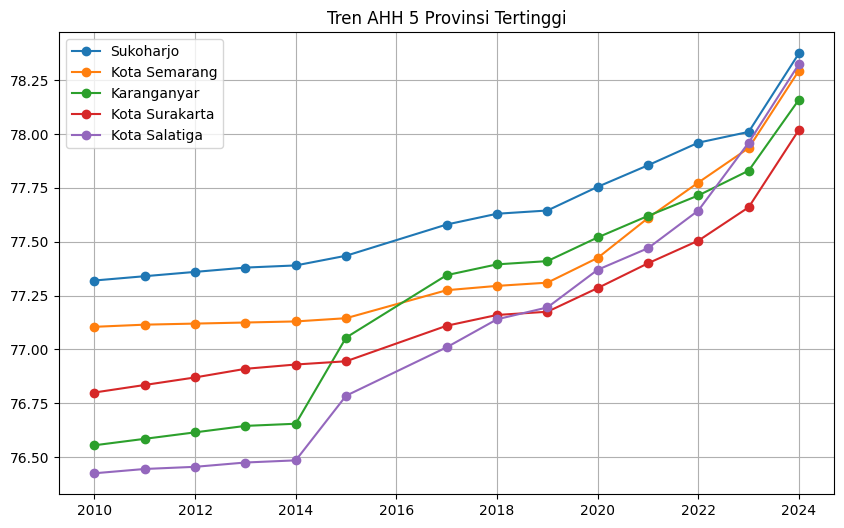

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/tren_ahh_top5_provinsi.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

df_plot = (
    df.groupby(["Kabupaten_Provinsi", "Tahun"])["Nilai"]
      .mean()
      .reset_index()
)

top10 = (
    df_plot.groupby("Kabupaten_Provinsi")["Nilai"]
      .mean()
      .sort_values(ascending=False)
      .head(5)
)
top5 = top10.index

plt.figure(figsize=(10,6))
for prov in top5:
    subset = df_plot[df_plot["Kabupaten_Provinsi"] == prov]
    plt.plot(subset["Tahun"], subset["Nilai"], marker="o", label=prov)

plt.title("Tren AHH 5 Provinsi Tertinggi")
plt.legend()
plt.grid(True)

save_path = os.path.join(drive_folder, "tren_ahh_top5_provinsi.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")

plt.show()

print("Gambar berhasil disimpan di:", save_path)

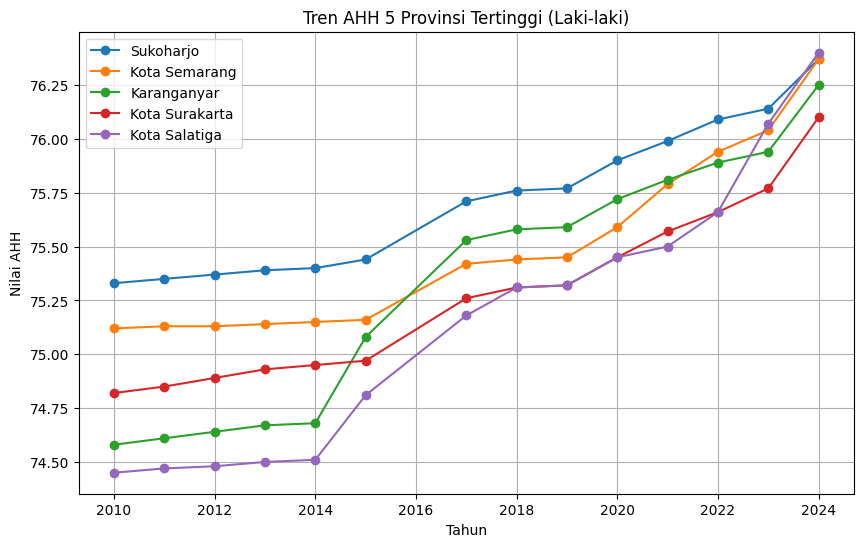

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/tren_ahh_top5_laki_laki.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

df_male = df[df["Jenis Kelamin"] == "Laki-laki"]
df_plot_male = (
    df_male.groupby(["Kabupaten_Provinsi", "Tahun"])["Nilai"]
           .mean()
           .reset_index()
)

top10male = (
    df_plot_male.groupby("Kabupaten_Provinsi")["Nilai"]
                .mean()
                .sort_values(ascending=False)
                .head(5)
)
top5 = top10male.index

plt.figure(figsize=(10,6))
for prov in top5:
    subset = df_plot_male[df_plot_male["Kabupaten_Provinsi"] == prov]
    plt.plot(subset["Tahun"], subset["Nilai"], marker="o", label=prov)

plt.title("Tren AHH 5 Provinsi Tertinggi (Laki-laki)")
plt.xlabel("Tahun")
plt.ylabel("Nilai AHH")
plt.legend()
plt.grid(True)

save_path = os.path.join(drive_folder, "tren_ahh_top5_laki_laki.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gambar berhasil disimpan di:", save_path)

In [ ]:
top10male

,Nilai
Kabupaten_Provinsi,
Sukoharjo,75.715000
Kota Semarang,75.490714
Karanganyar,75.326429
Kota Surakarta,75.275000
Kota Salatiga,75.150714
Kota Magelang,74.846429
Klaten,74.810000
Kudus,74.642143
Wonogiri,74.132857


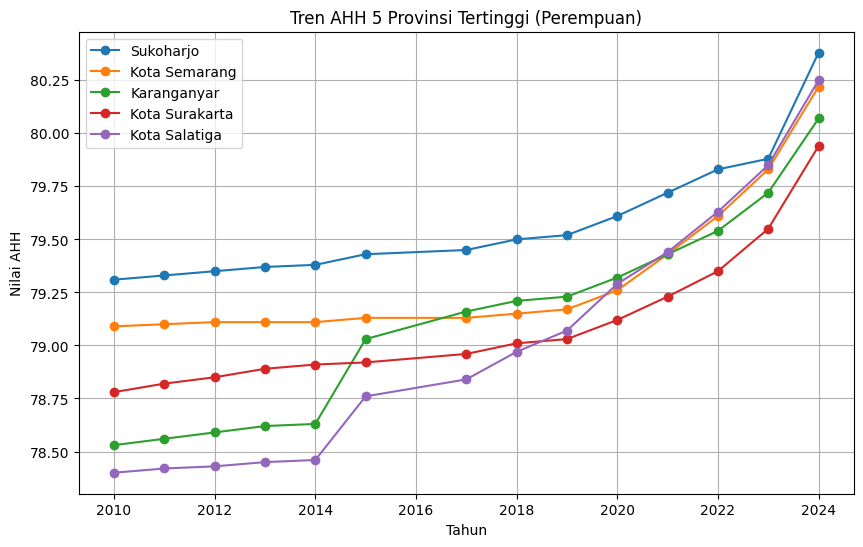

Gambar berhasil disimpan di: /content/drive/Shared drives/Wrangling/output/EDA/tren_ahh_top5_perempuan.png


In [ ]:
drive_folder = "/content/drive/Shared drives/Wrangling/output/EDA"
os.makedirs(drive_folder, exist_ok=True)

df_female = df[df["Jenis Kelamin"] == "Perempuan"]
df_plot_female = (
    df_female.groupby(["Kabupaten_Provinsi", "Tahun"])["Nilai"]
             .mean()
             .reset_index()
)
top10female = (
    df_plot_female.groupby("Kabupaten_Provinsi")["Nilai"]
                  .mean()
                  .sort_values(ascending=False)
                  .head(5)
)
top5 = top10female.index

plt.figure(figsize=(10,6))
for prov in top5:
    subset = df_plot_female[df_plot_female["Kabupaten_Provinsi"] == prov]
    plt.plot(subset["Tahun"], subset["Nilai"], marker="o", label=prov)

plt.title("Tren AHH 5 Provinsi Tertinggi (Perempuan)")
plt.xlabel("Tahun")
plt.ylabel("Nilai AHH")
plt.legend()
plt.grid(True)

save_path = os.path.join(drive_folder, "tren_ahh_top5_perempuan.png")
plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gambar berhasil disimpan di:", save_path)

In [ ]:
top10female

,Nilai
Kabupaten_Provinsi,
Sukoharjo,79.575714
Kota Semarang,79.317857
Karanganyar,79.117143
Kota Surakarta,79.097143
Kota Salatiga,79.018571
Kota Magelang,78.676429
Klaten,78.631429
Kudus,78.499286
Wonogiri,77.950000


Membentuk data analisis untuk langkah selanjutnya

In [ ]:
summary_yearly = df.groupby("Tahun")["Nilai"].agg(["mean","median","min","max","std"])
summary_yearly

,mean,median,min,max,std
Tahun,,,,,
2010,68.220610,68.350,50.98,79.31,4.177809
2011,68.252795,68.380,51.42,79.33,4.156780
2012,68.325329,68.420,51.74,79.35,4.129175
2013,68.365703,68.460,51.86,79.37,4.115699
2014,68.434991,68.490,51.92,79.38,4.084502
2015,68.633348,68.680,52.42,79.43,4.029995
2016,69.448714,69.220,62.49,76.54,3.245416
2017,68.878129,68.950,52.92,79.45,4.005867
2018,69.078138,69.120,53.17,79.50,3.967374


In [ ]:
summary_province = df.groupby("Kabupaten_Provinsi")["Nilai"].agg(["mean","median","min","max","std"])
summary_province

,mean,median,min,max,std
Kabupaten_Provinsi,,,,,
Aceh,67.812460,67.755,60.72,73.47,2.984672
Aceh Barat,67.668571,67.770,65.20,70.52,2.040219
Aceh Barat Daya,64.440000,64.490,61.55,67.63,2.073723
Aceh Besar,69.633929,69.795,67.34,72.31,2.009572
Aceh Jaya,66.836429,66.935,64.35,69.73,2.029178
...,...,...,...,...,...
Way Kanan,68.761786,68.870,65.67,72.18,2.173148
Wonogiri,76.041429,76.215,73.56,78.84,1.983901
Wonosobo,71.312857,71.315,68.44,74.45,2.069394


In [ ]:
summary_gender = df.groupby("Jenis Kelamin")["Nilai"].agg(["mean","median","min","max","std"])
summary_gender

,mean,median,min,max,std
Jenis Kelamin,,,,,
Laki-laki,67.208126,67.44,50.98,76.40,3.553785
Perempuan,71.031410,71.32,54.22,80.38,3.597133


In [ ]:
df_model = df[["Kabupaten_Provinsi","Jenis Kelamin","Tahun","Nilai"]].dropna()
df_model.to_csv("dataset_ready_for_model.csv", index=False)
df_model.head()

,Kabupaten_Provinsi,Jenis Kelamin,Tahun,Nilai
0,Aceh,Laki-laki,2010,67.17
1,Simeulue,Laki-laki,2010,62.15
2,Aceh Singkil,Laki-laki,2010,64.76
3,Aceh Selatan,Laki-laki,2010,61.04
4,Aceh Tenggara,Laki-laki,2010,64.90
